<a href="https://colab.research.google.com/github/letscode011/Convolution/blob/feat%2Fscatter/SimpleConvolution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1D Vectors

Importing numpy and matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Creating a evenly spaced 1D dataset within range [-1, 1]

In [ ]:
xi = np.linspace(-1, 1, 100)
yi = 0.1*(xi + np.power(xi, 2) + np.power(xi,3))

Function to generate evenly spaced 1D vector with user defined number of samples within range [-1, 1]

In [ ]:
def create_dataset(n_samples=100):
  xi = np.linspace(-1, 1, n_samples)
  yi = 0.1*(xi + np.power(xi, 2) + np.power(xi,3))
  return xi, yi

In [ ]:
create_dataset(50)

(array([-1.        , -0.95918367, -0.91836735, -0.87755102, -0.83673469,
        -0.79591837, -0.75510204, -0.71428571, -0.67346939, -0.63265306,
        -0.59183673, -0.55102041, -0.51020408, -0.46938776, -0.42857143,
        -0.3877551 , -0.34693878, -0.30612245, -0.26530612, -0.2244898 ,
        -0.18367347, -0.14285714, -0.10204082, -0.06122449, -0.02040816,
         0.02040816,  0.06122449,  0.10204082,  0.14285714,  0.18367347,
         0.2244898 ,  0.26530612,  0.30612245,  0.34693878,  0.3877551 ,
         0.42857143,  0.46938776,  0.51020408,  0.55102041,  0.59183673,
         0.63265306,  0.67346939,  0.71428571,  0.75510204,  0.79591837,
         0.83673469,  0.87755102,  0.91836735,  0.95918367,  1.        ]),
 array([-0.1       , -0.09216313, -0.08495185, -0.07832536, -0.07224286,
        -0.06666355, -0.06154663, -0.05685131, -0.05253678, -0.04856225,
        -0.04488691, -0.04146997, -0.03827062, -0.03524807, -0.03236152,
        -0.02957016, -0.02683321, -0.02410985, -0

Creating a class with a instance method to create user defined evenly spaced 1D vector within range [-1, 1]

In [ ]:
class Dataset:
  def __init__(self, n_samples=100):
    self.n_samples = n_samples;

  def load_data(self):
    xi = np.linspace(-1, 1, self.n_samples)
    yi = 0.1*(xi + np.power(xi, 2) + np.power(xi,3))
    return xi, yi

In [ ]:
d = Dataset(20)

In [ ]:
d.load_data()

(array([-1.        , -0.89473684, -0.78947368, -0.68421053, -0.57894737,
        -0.47368421, -0.36842105, -0.26315789, -0.15789474, -0.05263158,
         0.05263158,  0.15789474,  0.26315789,  0.36842105,  0.47368421,
         0.57894737,  0.68421053,  0.78947368,  0.89473684,  1.        ]),
 array([-0.1       , -0.0810468 , -0.06582592, -0.05363756, -0.04378189,
        -0.03555912, -0.02826943, -0.021213  , -0.01369004, -0.00500073,
         0.00555475,  0.01867619,  0.03506342,  0.05541624,  0.08043447,
         0.1108179 ,  0.14726637,  0.19047966,  0.2411576 ,  0.3       ]))

([<matplotlib.axis.XTick at 0x7ad1194a81a0>,
 [Text(-1.0, 0, '−1.0'),
  Text(-0.5, 0, '−0.5'),
  Text(0.0, 0, '0.0'),
  Text(0.5, 0, '0.5'),
  Text(1.0, 0, '1.0')])

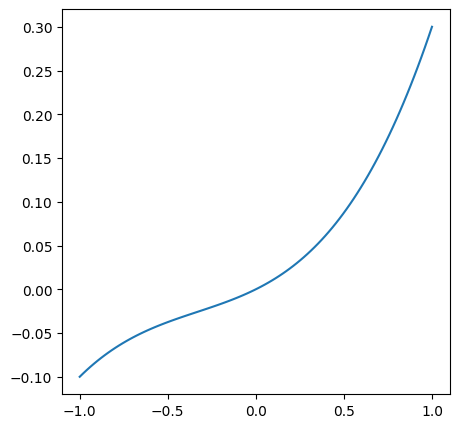

In [ ]:
plt.figure(figsize=(5,5))
plt.plot(xi, yi)
plt.xticks(np.linspace(min(xi), max(xi), 5))

# 2D Vectors

###Goal of fixing seed

The seeds makes the RNG deterministic.

https://numpy.org/doc/stable/reference/random/index.html

In [39]:
rng = np.random.default_rng(42)

In [40]:
xi = rng.standard_normal(100)
yi = np.where(xi*xi < 1, 0, 1)
ip = np.array([xi, yi]).T
ip

array([[ 0.30471708,  0.        ],
       [-1.03998411,  1.        ],
       [ 0.7504512 ,  0.        ],
       [ 0.94056472,  0.        ],
       [-1.95103519,  1.        ],
       [-1.30217951,  1.        ],
       [ 0.1278404 ,  0.        ],
       [-0.31624259,  0.        ],
       [-0.01680116,  0.        ],
       [-0.85304393,  0.        ],
       [ 0.87939797,  0.        ],
       [ 0.77779194,  0.        ],
       [ 0.0660307 ,  0.        ],
       [ 1.12724121,  1.        ],
       [ 0.46750934,  0.        ],
       [-0.85929246,  0.        ],
       [ 0.36875078,  0.        ],
       [-0.9588826 ,  0.        ],
       [ 0.8784503 ,  0.        ],
       [-0.04992591,  0.        ],
       [-0.18486236,  0.        ],
       [-0.68092954,  0.        ],
       [ 1.22254134,  1.        ],
       [-0.15452948,  0.        ],
       [-0.42832782,  0.        ],
       [-0.35213355,  0.        ],
       [ 0.53230919,  0.        ],
       [ 0.36544406,  0.        ],
       [ 0.41273261,

We can pass array of mixed colors to the **c** (color) parameter of scatter plot. The same can't be done for markers, in case of markers we need different calls for different cases

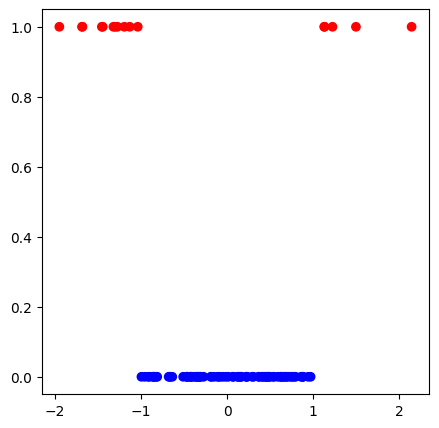

In [41]:
plt.figure(figsize=(5,5))
colors = np.where(yi == 0, "blue", "red")
plt.scatter(xi,yi, c=colors)

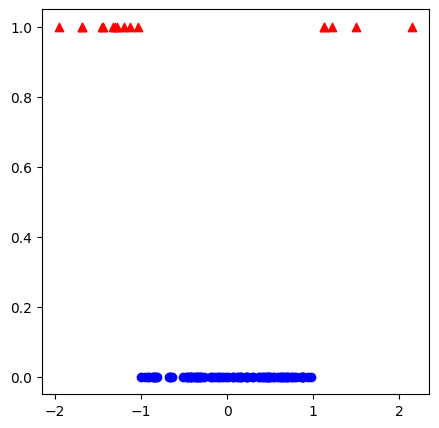

In [43]:
plt.figure(figsize=(5,5))
plt.scatter(xi[yi==0], yi[yi==0], c= "blue", marker="o")
plt.scatter(xi[yi==1], yi[yi==1], c= "red", marker="^")

# Convolution and Matrices

Input matrix X

In [24]:
X = np.array([[0,1,2,3],
             [4,5,6,7],
             [8,9,10,11],
             [12,13,14,15]
              ])

In [4]:
X.shape

(4, 4)

Kernel with size 2x2

In [25]:
W = np.ones((2,2))
W.shape[0]

2

##Convolution
The input matrix is multipled with kernel and then summed. The output has smaller size gievn by the formulae:
***Y = X - W + 1***

In [36]:
def Conv(X,W):
  Y = np.zeros((X.shape[0] - W.shape[0] + 1, X.shape[0] - W.shape[0] + 1))
  for i in range(X.shape[0] - W.shape[0] + 1):
    for j in range(X.shape[0] - W.shape[0] + 1):
      ip = X[i: i+W.shape[0], j: j+W.shape[0]]
      Y[i,j] = np.sum(ip * W)
  return Y


In [37]:
Conv(X,W)

array([[10., 14., 18.],
       [26., 30., 34.],
       [42., 46., 50.]])